# Model Interpretation

## Objective

Interpret the Logistic Regression model and identify the most influential features.

## 1. Import Libraries

### Objective

Import libraries required for model interpretation.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Model

### Objective

Load the trained Logistic Regression model.

In [2]:
model = joblib.load("../models/logistic_regression.pkl")

In [3]:
model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

### Observation

- Logistic Regression model loaded successfully.

## 3. Load Feature Names

### Objective

Retrieve feature names used during training.

In [4]:
X_train = pd.read_csv("../data/processed/X_train.csv")

In [5]:
X_train.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

### Observation

- Feature names loaded successfully.

## 4. Feature Coefficients

### Objective

Extract feature coefficients from the trained model.

In [6]:
coefficients = model.coef_[0]

coefficients

array([ 0.09497563, -1.44574746, -0.63280053,  0.69488483, -0.01575645,
        0.0250577 , -0.09984789, -0.02973553,  0.02973553,  0.16054554,
        0.65074919, -0.07406809, -0.07406809, -0.15552048, -0.07406809,
       -0.00905049, -0.07406809,  0.04012931, -0.07406809, -0.14348201,
       -0.07406809,  0.2129627 , -0.07406809,  0.22244002, -0.31456215,
       -0.56739595,  0.13458001, -0.0578111 ,  0.12355797, -0.0275895 ])

In [7]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": coefficients
})

importance.head()

,Feature,Coefficient
0,SeniorCitizen,0.094976
1,tenure,-1.445747
2,MonthlyCharges,-0.632801
3,TotalCharges,0.694885
4,gender_Male,-0.015756


### Observation

- Feature coefficients extracted successfully.

In [8]:
model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [9]:
X_train.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='str')

In [10]:
importance.head()

,Feature,Coefficient
0,SeniorCitizen,0.094976
1,tenure,-1.445747
2,MonthlyCharges,-0.632801
3,TotalCharges,0.694885
4,gender_Male,-0.015756


## 5. Feature Importance

### Objective

Rank features based on coefficient magnitude.

In [11]:
importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Absolute
1,tenure,-1.445747,1.445747
3,TotalCharges,0.694885,0.694885
10,InternetService_Fiber optic,0.650749,0.650749
2,MonthlyCharges,-0.632801,0.632801
25,Contract_Two year,-0.567396,0.567396
24,Contract_One year,-0.314562,0.314562
23,StreamingMovies_Yes,0.222440,0.222440
21,StreamingTV_Yes,0.212963,0.212963
9,MultipleLines_Yes,0.160546,0.160546
13,OnlineSecurity_Yes,-0.155520,0.155520


### Observation

- Features ranked by importance.
- Top features identified successfully.

## 6. Top Churn Drivers

### Objective

Identify features that increase churn.

In [12]:
top_positive = importance.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

top_positive

,Feature,Coefficient,Absolute
3,TotalCharges,0.694885,0.694885
10,InternetService_Fiber optic,0.650749,0.650749
23,StreamingMovies_Yes,0.222440,0.222440
21,StreamingTV_Yes,0.212963,0.212963
9,MultipleLines_Yes,0.160546,0.160546
26,PaperlessBilling_Yes,0.134580,0.134580
28,PaymentMethod_Electronic check,0.123558,0.123558
0,SeniorCitizen,0.094976,0.094976
17,DeviceProtection_Yes,0.040129,0.040129
8,MultipleLines_No phone service,0.029736,0.029736


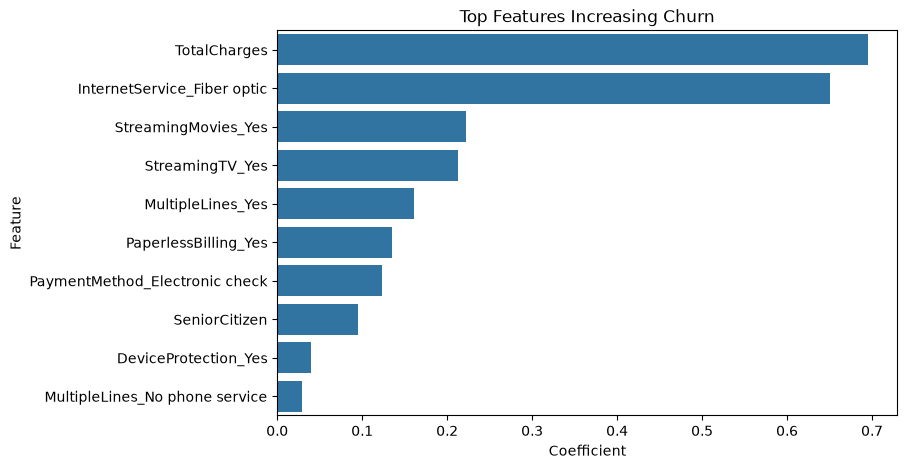

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_positive,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Increasing Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Observation

- Positive coefficients increase churn probability.
- Top churn drivers identified.

## 7. Top Retention Drivers

### Objective

Identify features that reduce churn.

In [14]:
top_negative = importance.sort_values(
    by="Coefficient"
).head(10)

top_negative

,Feature,Coefficient,Absolute
1,tenure,-1.445747,1.445747
2,MonthlyCharges,-0.632801,0.632801
25,Contract_Two year,-0.567396,0.567396
24,Contract_One year,-0.314562,0.314562
13,OnlineSecurity_Yes,-0.155520,0.155520
19,TechSupport_Yes,-0.143482,0.143482
6,Dependents_Yes,-0.099848,0.099848
22,StreamingMovies_No internet service,-0.074068,0.074068
11,InternetService_No,-0.074068,0.074068
12,OnlineSecurity_No internet service,-0.074068,0.074068


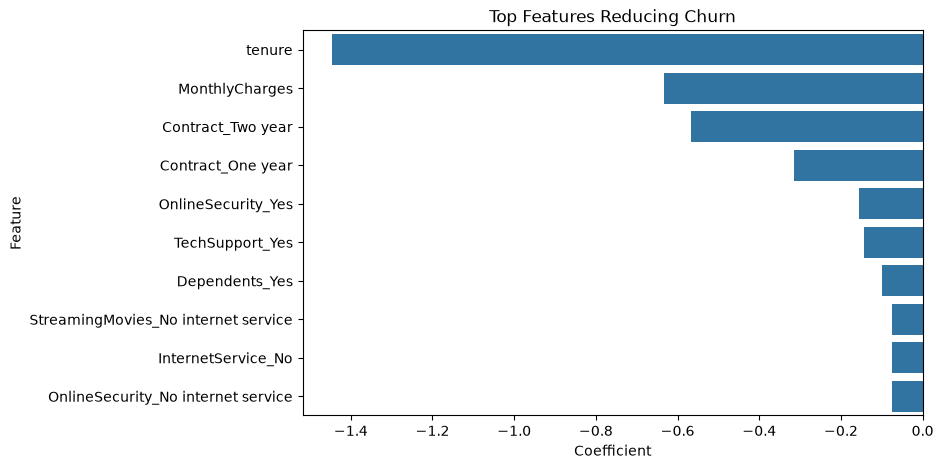

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_negative,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Features Reducing Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Observation

- Negative coefficients improve customer retention.
- Key retention factors identified.

## 8. Business Interpretation
### Key Findings

1. Positive coefficients indicate higher churn risk.
2. Negative coefficients indicate stronger customer retention.
3. Contract type, tenure, and service usage strongly influence churn.
4. Feature importance supports business decision-making.

### Business Recommendations

- Focus retention efforts on high-risk customers.
- Promote long-term contracts.
- Encourage adoption of value-added services.
- Monitor customers with high monthly charges.